In [2]:
import torch
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio, display

print(f"torch {torch.__version__}, torchaudio {torchaudio.__version__}")

# knn-vc's own hub loader only checks CUDA (see hubconf.py: wavlm_large falls back to
# cpu if no CUDA, but hifigan_wavlm does not) -- mixing cuda-absent + mps present would
# leave encoder and vocoder on different devices. Stick to cuda -> cpu to avoid that bug.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device: {device}")

torch 2.13.0, torchaudio 2.11.0
using device: cpu


In [3]:
knn_vc = torch.hub.load(
    "bshall/knn-vc", "knn_vc",
    prematched=True, trust_repo=True, pretrained=True, device=device,
)

n_wavlm = sum(p.numel() for p in knn_vc.wavlm.parameters())
n_hifigan = sum(p.numel() for p in knn_vc.hifigan.parameters())
print(f"WavLM-Large encoder:  {n_wavlm:,} params (frozen)")
print(f"HiFi-GAN vocoder:     {n_hifigan:,} params (frozen)")
print(f"sample rate:          {knn_vc.sr} Hz")
print(f"hop length:           {knn_vc.hop_length} samples -> {1000 * knn_vc.hop_length / knn_vc.sr:.0f} ms/frame")


Using cache found in /Users/prashant/.cache/torch/hub/bshall_knn-vc_master
/Users/prashant/Desktop/Projects/paper/knn-vc/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Removing weight norm...
[HiFiGAN] Generator loaded with 16,523,393 parameters.
WavLM-Large loaded with 315,453,120 parameters.
WavLM-Large encoder:  315,453,120 params (frozen)
HiFi-GAN vocoder:     16,523,393 params (frozen)
sample rate:          16000 Hz
hop length:           320 samples -> 20 ms/frame


In [4]:
wavlm = knn_vc.wavlm
wavlm

WavLM(
  (feature_extractor): ConvFeatureExtractionModel(
    (conv_layers): ModuleList(
      (0): Sequential(
        (0): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (1): Dropout(p=0.0, inplace=False)
        (2): Sequential(
          (0): TransposeLast()
          (1): Fp32LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (2): TransposeLast()
        )
        (3): GELU(approximate='none')
      )
      (1-4): 4 x Sequential(
        (0): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (1): Dropout(p=0.0, inplace=False)
        (2): Sequential(
          (0): TransposeLast()
          (1): Fp32LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (2): TransposeLast()
        )
        (3): GELU(approximate='none')
      )
      (5-6): 2 x Sequential(
        (0): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (1): Dropout(p=0.0, inplace=False)
        (2): Sequential(
    

In [5]:
conv = knn_vc.wavlm.feature_extractor.conv_layers[0][0]   # this Conv1d
ln   = knn_vc.wavlm.feature_extractor.conv_layers[0][2][1]  # the Fp32LayerNorm inside

In [6]:
conv.weight      # shape (512, 1, 10) — 512 output channels, 1 input channel (mono audio), kernel width 10

Parameter containing:
tensor([[[ 0.0007, -0.0043,  0.0040,  ...,  0.0075,  0.0019,  0.0009]],

        [[ 0.0014, -0.0040,  0.0039,  ...,  0.0068,  0.0018,  0.0010]],

        [[ 0.0143,  0.0028,  0.0139,  ..., -0.0103, -0.0482,  0.0603]],

        ...,

        [[ 0.0100, -0.0367,  0.0694,  ..., -0.0900,  0.0567, -0.0154]],

        [[ 0.0011, -0.0047,  0.0034,  ...,  0.0071,  0.0012,  0.0005]],

        [[ 0.0011, -0.0041,  0.0039,  ...,  0.0066,  0.0014,  0.0006]]],
       requires_grad=True)

In [7]:
conv.weight.shape, conv.weight.numel()  # 5,120 numbers total in this one conv, no bias (bias=False)

(torch.Size([512, 1, 10]), 5120)

In [8]:
ln.weight, ln.bias   # each shape (512,) — LayerNorm's learned scale/shift per channel

(Parameter containing:
 tensor([0.1857, 0.1874, 0.2418, 0.1870, 0.1866, 0.1853, 0.1868, 0.1853, 0.1862,
         0.1857, 0.1868, 0.1855, 0.1854, 0.2291, 0.1855, 0.1857, 0.1844, 0.1848,
         0.1844, 0.1875, 0.1851, 0.3003, 0.1868, 0.1848, 0.1852, 0.6133, 0.1860,
         0.1841, 0.1854, 0.1853, 0.1848, 0.1858, 0.1855, 0.2419, 0.1859, 0.1849,
         0.1862, 0.1884, 0.1851, 0.1858, 0.1858, 0.1849, 0.2069, 0.1854, 0.1857,
         0.1875, 0.1857, 0.1860, 0.1865, 0.1864, 0.1854, 0.1854, 0.2576, 0.2234,
         0.1852, 0.1847, 0.1860, 0.1846, 0.1847, 0.3267, 0.1862, 0.1852, 0.1855,
         0.1854, 0.3142, 0.1852, 0.1852, 0.1871, 0.1851, 0.1868, 0.2010, 0.1858,
         0.1863, 0.1865, 0.1858, 0.1851, 0.1849, 0.1862, 0.1853, 0.1862, 0.2076,
         0.1840, 0.2078, 0.1844, 0.1870, 0.1860, 0.1859, 0.5996, 0.1868, 0.1869,
         0.1862, 0.1847, 0.1862, 0.1852, 0.1859, 0.1860, 0.1848, 0.1860, 0.1862,
         0.1864, 0.8740, 0.1849, 0.1863, 0.1862, 0.2179, 0.1847, 0.1851, 0.1860,
     

In [9]:
hifigan=knn_vc.hifigan
hifigan

Generator(
  (lin_pre): Linear(in_features=1024, out_features=512, bias=True)
  (conv_pre): Conv1d(512, 512, kernel_size=(7,), stride=(1,), padding=(3,))
  (ups): ModuleList(
    (0): ConvTranspose1d(512, 256, kernel_size=(20,), stride=(10,), padding=(5,))
    (1): ConvTranspose1d(256, 128, kernel_size=(16,), stride=(8,), padding=(4,))
    (2): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
    (3): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  )
  (resblocks): ModuleList(
    (0): ResBlock1(
      (convs1): ModuleList(
        (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(3,), dilation=(3,))
        (2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(5,), dilation=(5,))
      )
      (convs2): ModuleList(
        (0-2): 3 x Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      )
    )
    (1): ResBlock1(
      (convs1): Modu

## Working with Data

In [ ]:
from torchaudio.datasets import LIBRISPEECH

dataset = LIBRISPEECH(root="./data", url="dev-clean", download=True)

Each Dataset Has Following
  - waveform — Tensor, shape [1, N]
  - sample_rate — int, 16000
  - transcript — str, uppercase text
  - speaker_id — int
  - chapter_id — int
  - utterance_id — int, index within chapter

In [13]:
dataset[0]

(tensor([[0.0024, 0.0021, 0.0020,  ..., 0.0004, 0.0006, 0.0010]]),
 16000,
 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL',
 1272,
 128104,
 0)

In [14]:
# get_metadata avoids decoding audio, just reads filenames -- fast way to group by speaker
speaker_to_indices = {}
for i in range(len(dataset)):
    _, _, _, speaker_id, _, _ = dataset.get_metadata(i)
    speaker_to_indices.setdefault(speaker_id, []).append(i)

In [ ]:
speakers = sorted(speaker_to_indices)
source_speaker, target_speaker = speakers[0], speakers[1]   # taking one speaker as source, another as target

source speaker: 84 (65 utterances)
target speaker: 174 (59 utterances)


In [21]:
print(f"source speaker: {source_speaker} ({len(speaker_to_indices[source_speaker])} utterances)")
print(f"target speaker: {target_speaker} ({len(speaker_to_indices[target_speaker])} utterances)")

source speaker: 84 (65 utterances)
target speaker: 174 (59 utterances)


In [19]:
source_wave, source_sr, source_text, *_ = dataset[speaker_to_indices[source_speaker][0]]
ref_indices = speaker_to_indices[target_speaker][:5]
ref_waves = [dataset[i][0] for i in ref_indices]

In [20]:
assert source_sr == knn_vc.sr, f"expected {knn_vc.sr}Hz, LibriSpeech gave {source_sr}Hz"
print(f"\nsource text: \"{source_text}\"")
print(f"source duration: {source_wave.shape[-1] / source_sr:.2f}s")
print(f"reference set: {len(ref_waves)} utterances, {sum(w.shape[-1] for w in ref_waves) / source_sr:.1f}s total")


source text: "GO DO YOU HEAR"
source duration: 2.09s
reference set: 5 utterances, 51.0s total


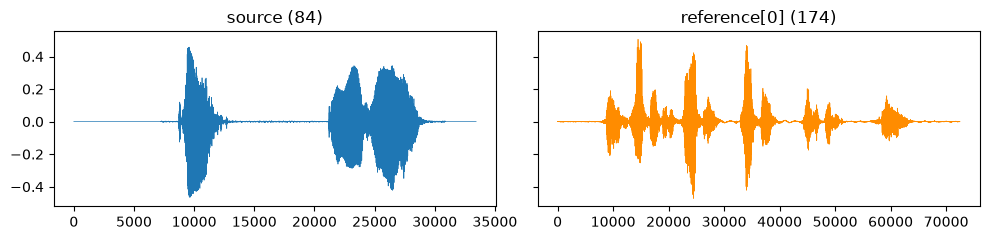

source:


reference[0]:


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2.5), sharey=True)
axes[0].plot(source_wave[0].numpy(), linewidth=0.5)
axes[0].set_title(f"source ({source_speaker})")
axes[1].plot(ref_waves[0][0].numpy(), linewidth=0.5, color="darkorange")
axes[1].set_title(f"reference[0] ({target_speaker})")
plt.tight_layout()
plt.show()

print("source:")
display(Audio(source_wave.numpy(), rate=source_sr))
print("reference[0]:")
display(Audio(ref_waves[0].numpy(), rate=source_sr))
